In [24]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
tf.compat.v1.enable_eager_execution()

# importing
df = pd.read_csv("forestfires.csv")
df

,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep,size_category
0,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,1,0,0,0,0,small
1,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,0,0,0,0,0,1,0,small
2,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0,0,0,1,0,small
3,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,1,0,0,0,0,small
4,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,0,0,0,0,1,0,0,0,0,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,0,0,0,0,0,0,0,0,0,large
513,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,0,0,0,0,0,0,0,0,0,large
514,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,0,0,0,0,0,0,0,0,0,large
515,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,...,0,0,0,0,0,0,0,0,0,small


In [25]:
df.duplicated().sum()

8

In [26]:
df=df.drop_duplicates()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 509 entries, 0 to 516
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          509 non-null    object 
 1   day            509 non-null    object 
 2   FFMC           509 non-null    float64
 3   DMC            509 non-null    float64
 4   DC             509 non-null    float64
 5   ISI            509 non-null    float64
 6   temp           509 non-null    float64
 7   RH             509 non-null    int64  
 8   wind           509 non-null    float64
 9   rain           509 non-null    float64
 10  area           509 non-null    float64
 11  dayfri         509 non-null    int64  
 12  daymon         509 non-null    int64  
 13  daysat         509 non-null    int64  
 14  daysun         509 non-null    int64  
 15  daythu         509 non-null    int64  
 16  daytue         509 non-null    int64  
 17  daywed         509 non-null    int64  
 18  monthapr  

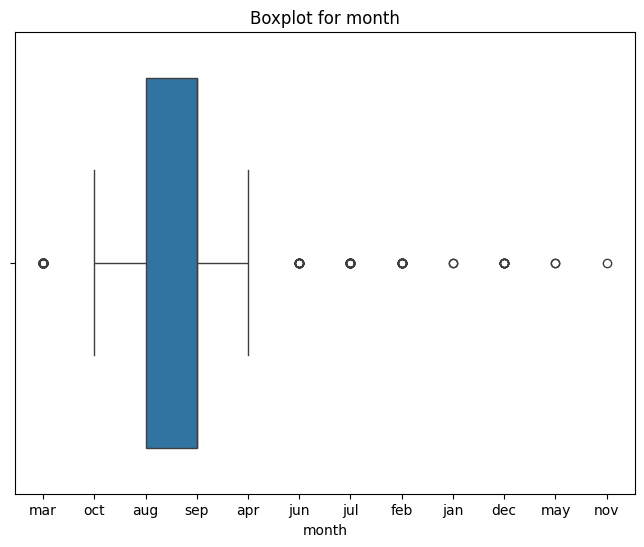

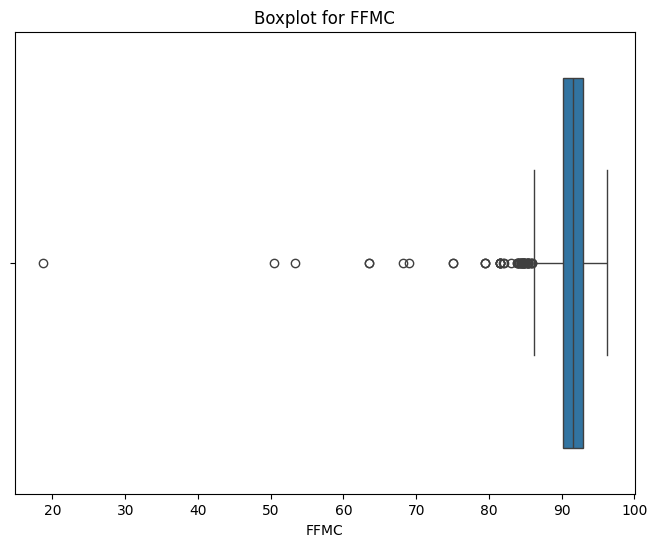

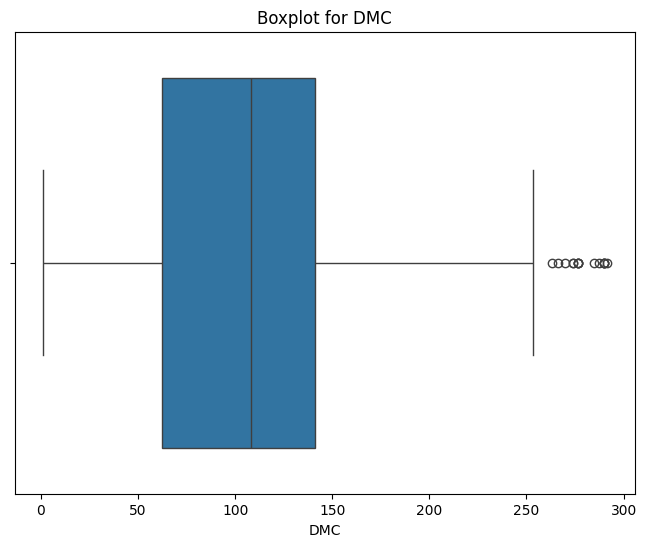

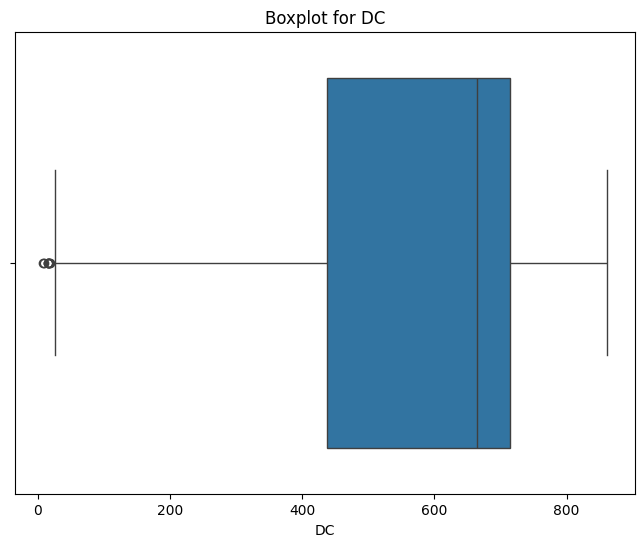

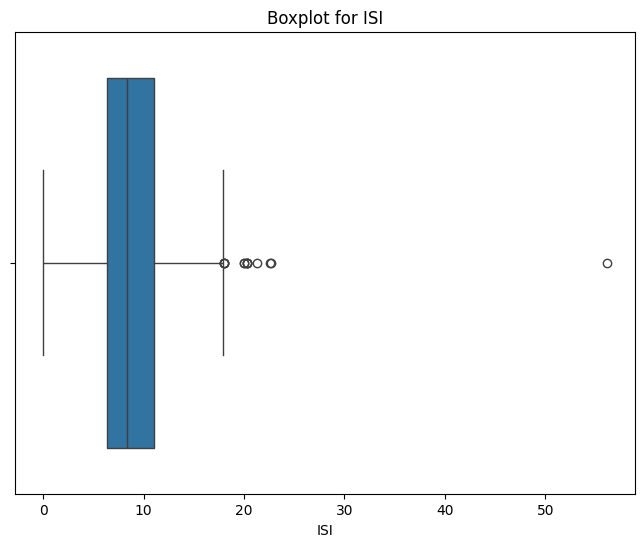

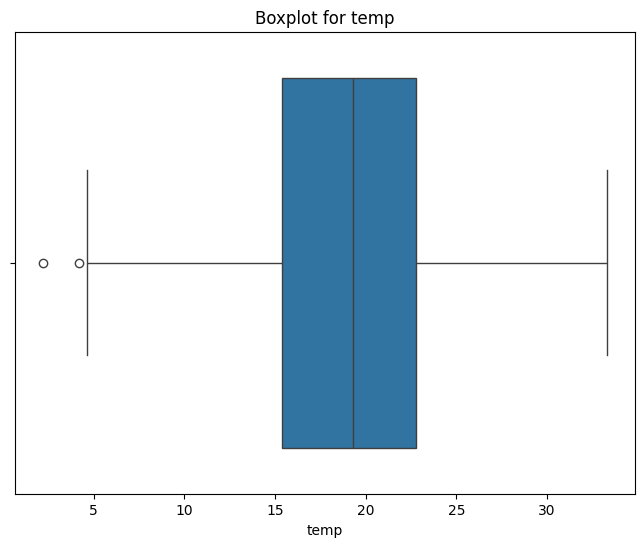

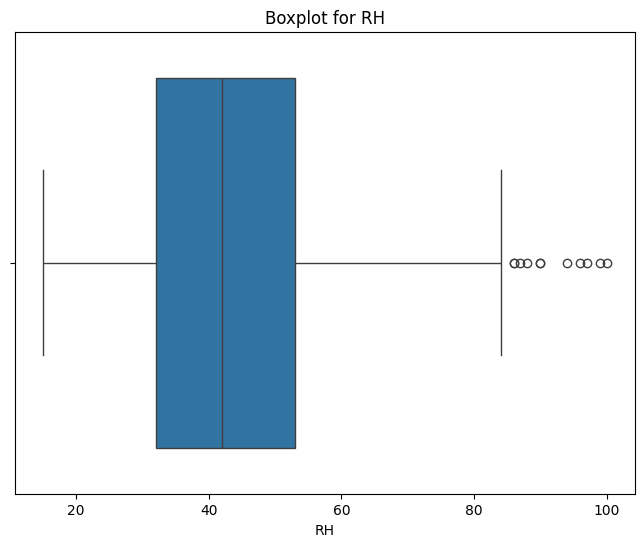

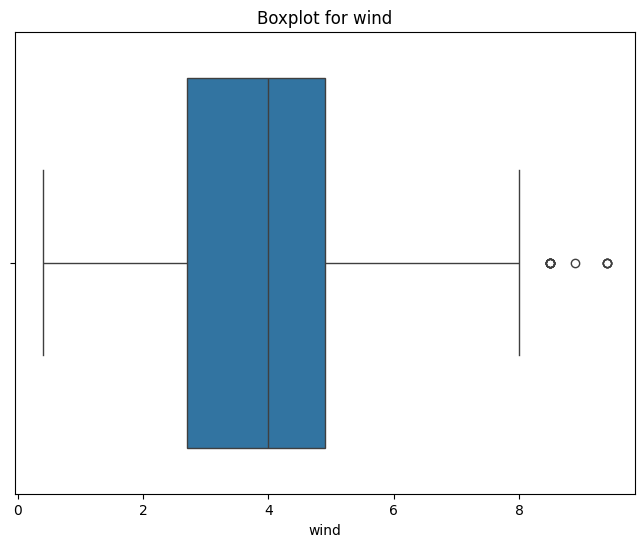

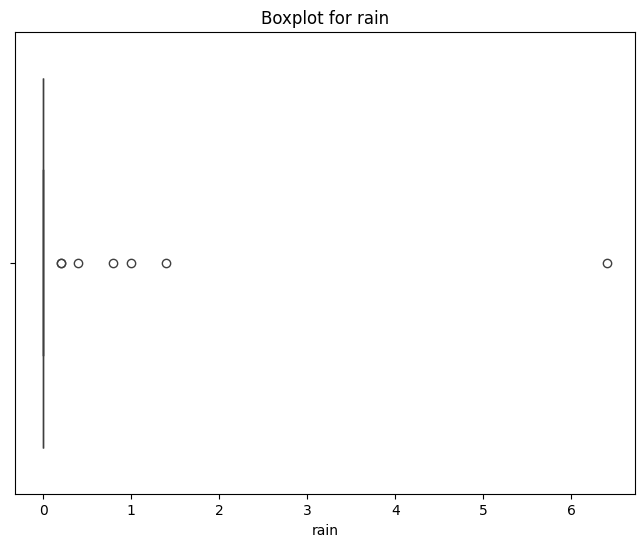

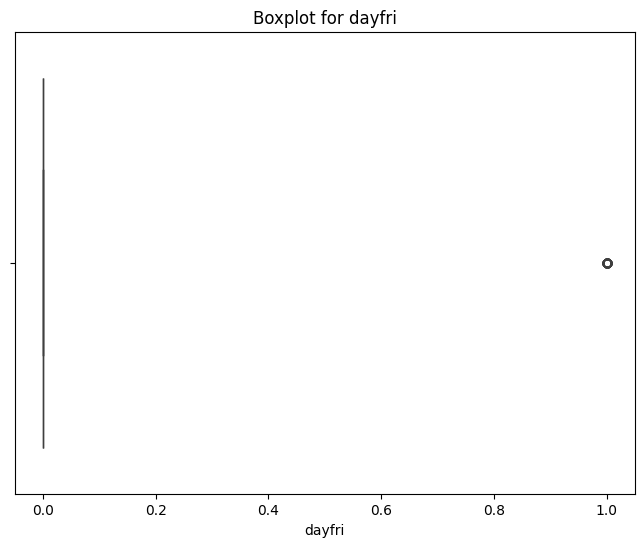

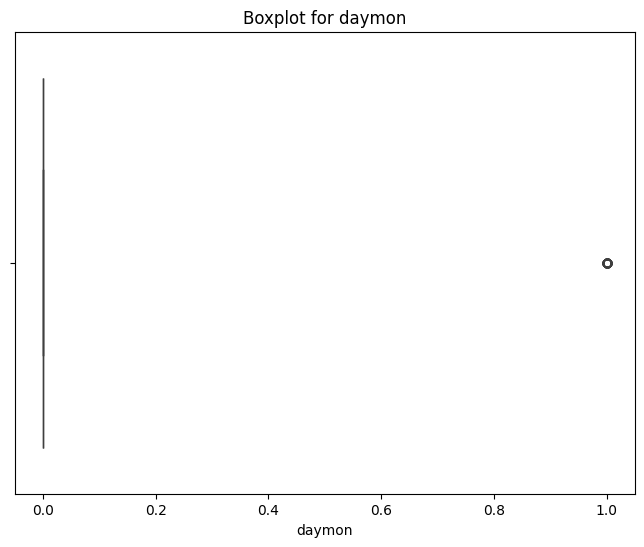

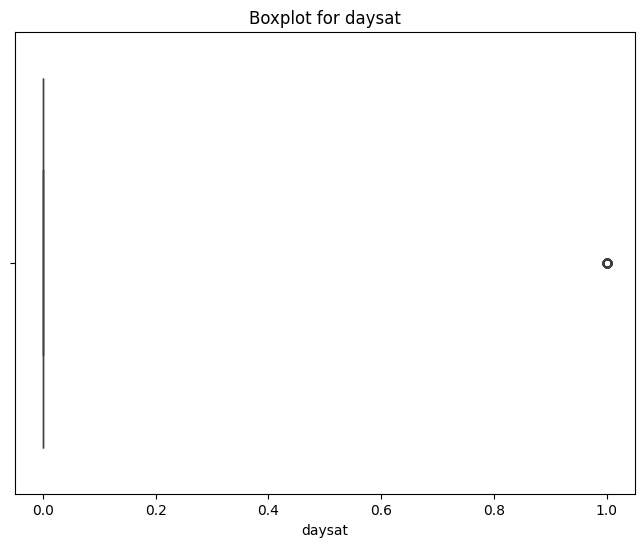

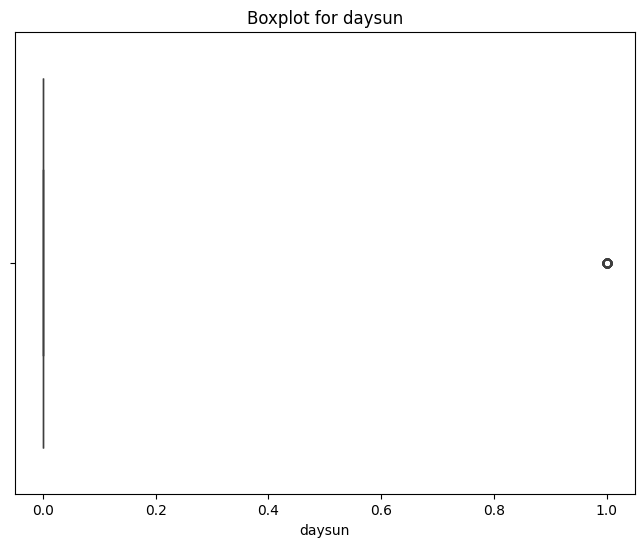

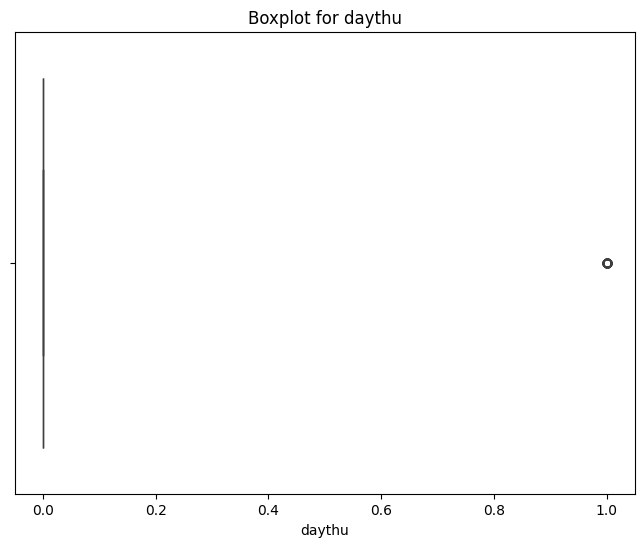

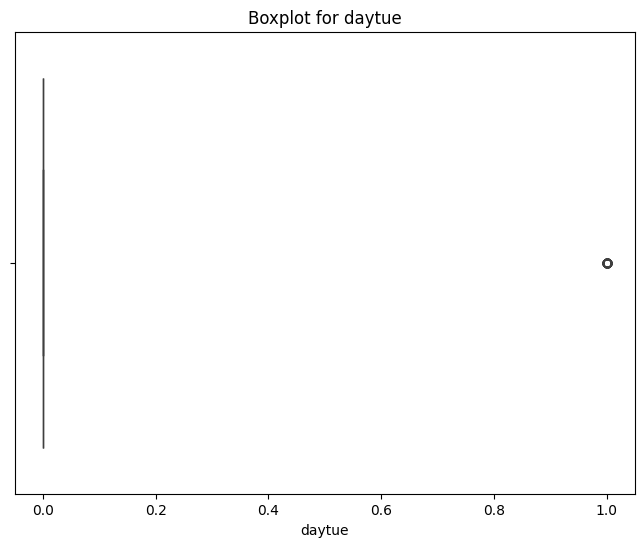

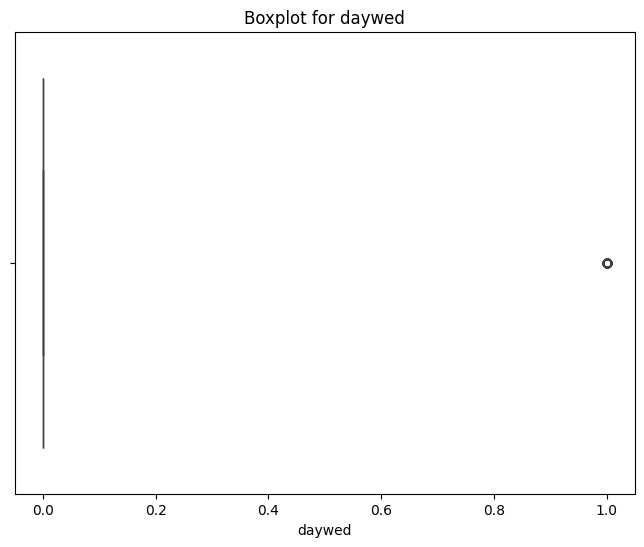

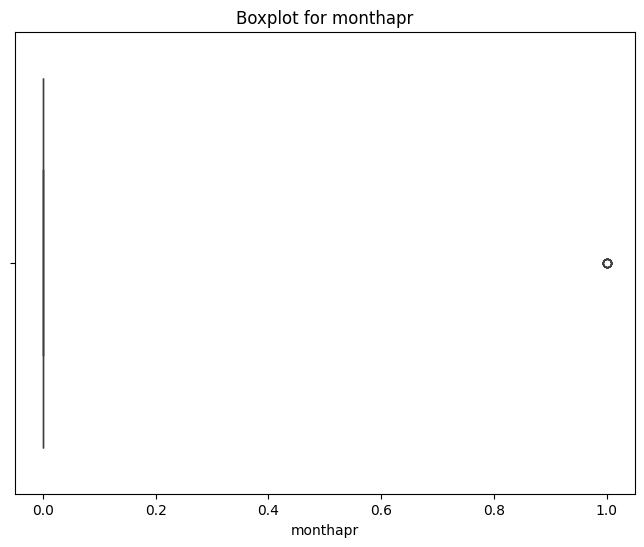

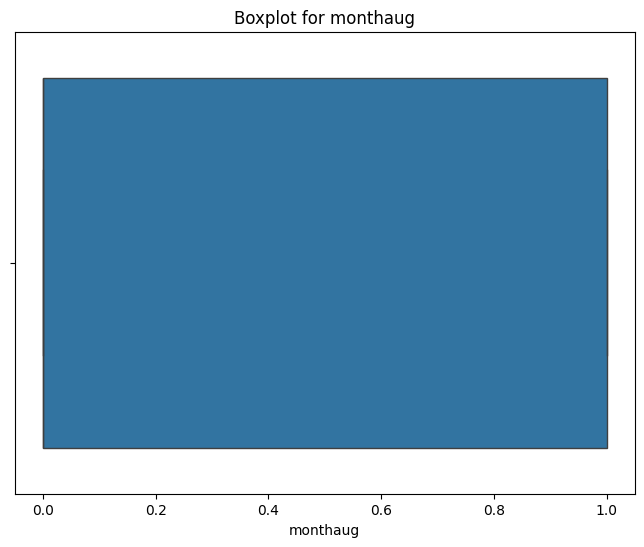

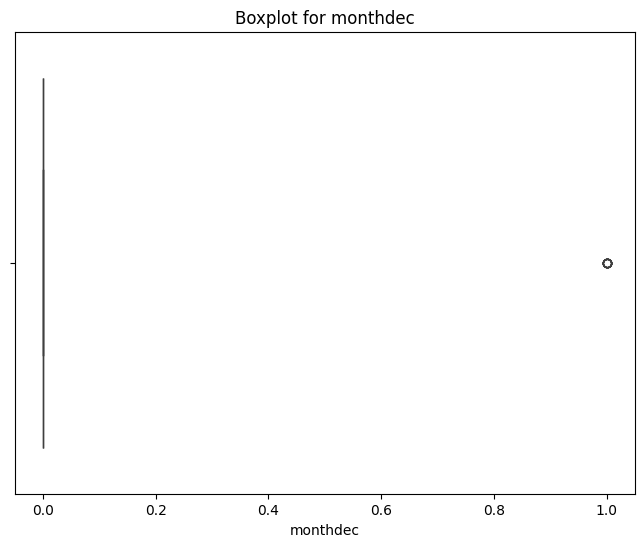

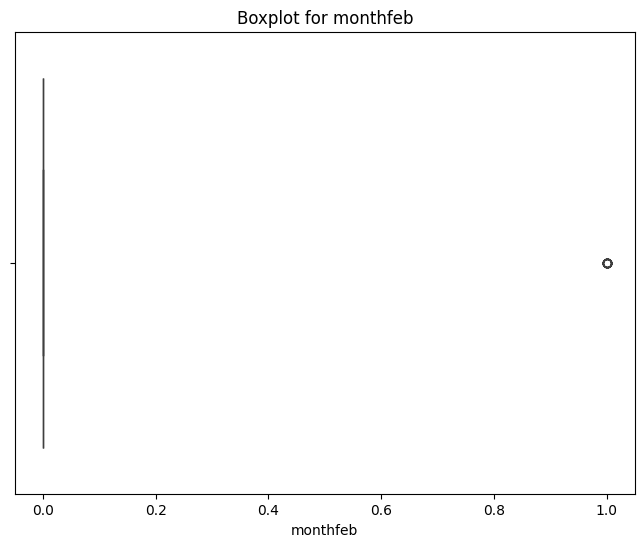

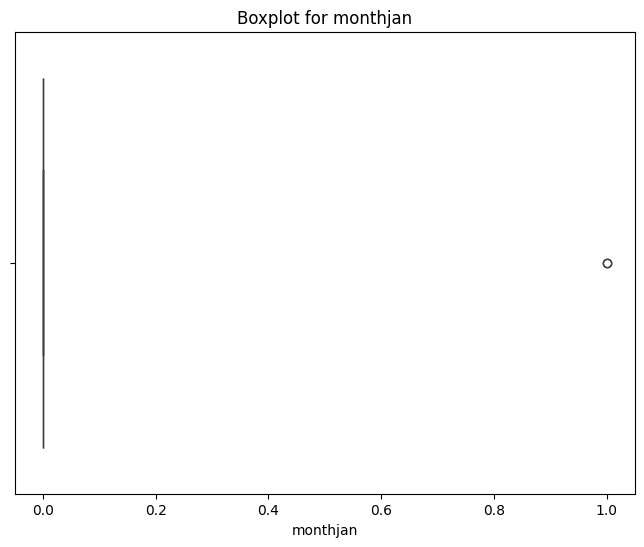

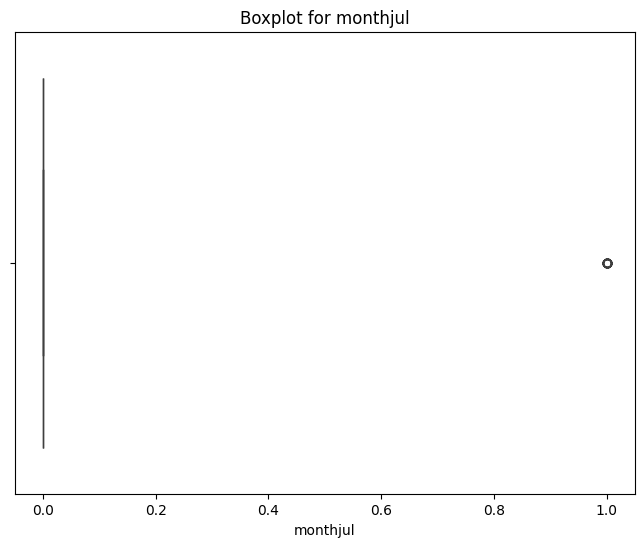

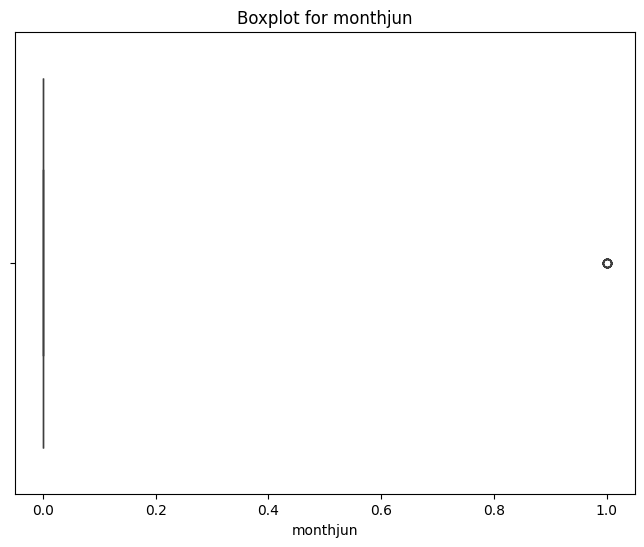

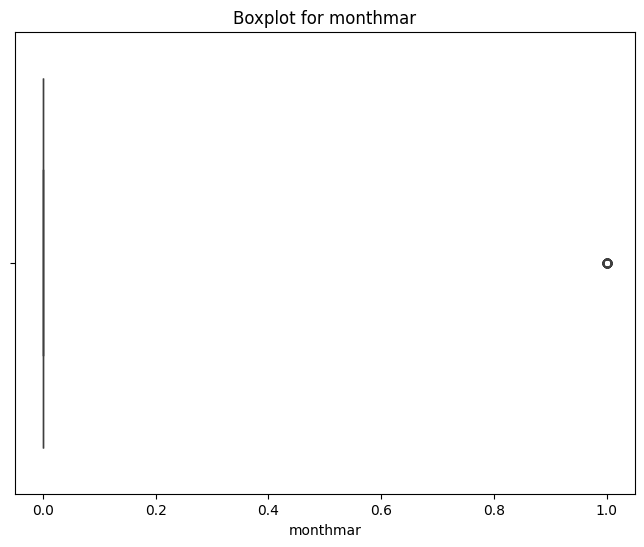

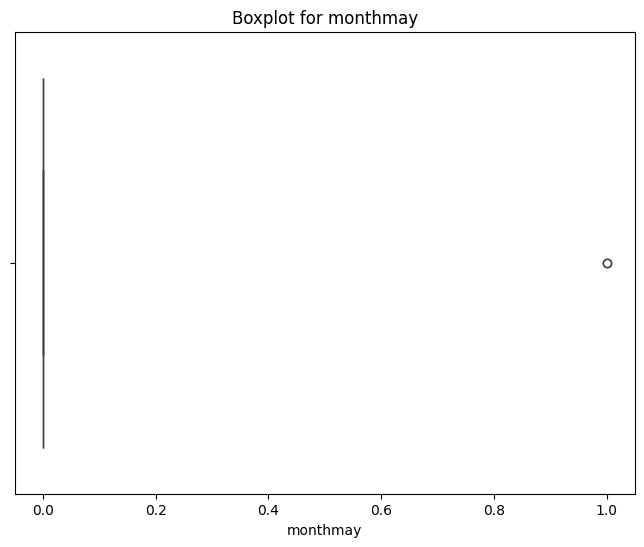

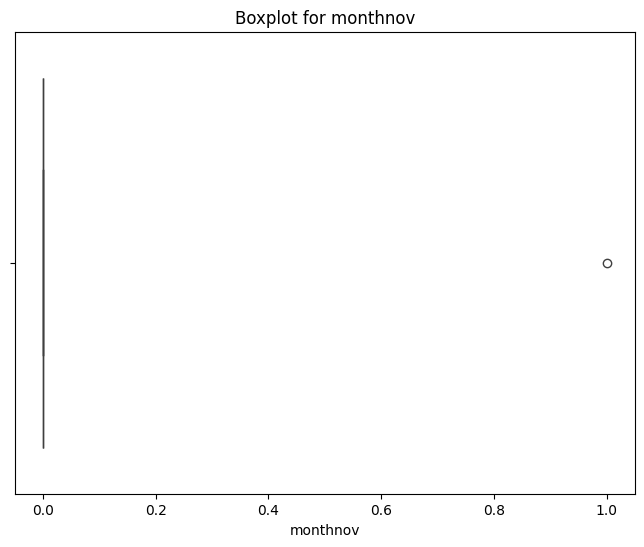

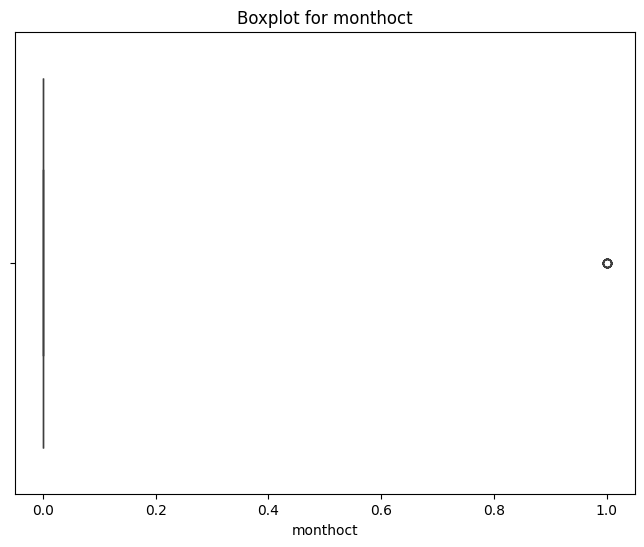

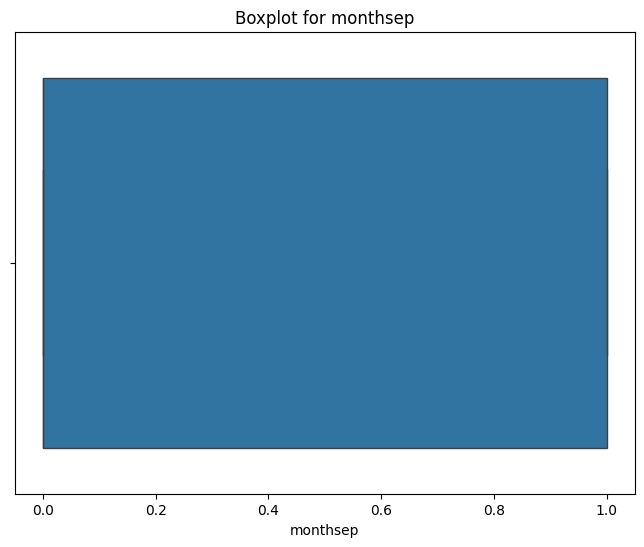

In [28]:
for column in df.columns:
    if column in numerical_columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[column])
        plt.title(f'Boxplot for {column}')
        plt.show()

In [29]:
def replace_outliers(data):
    for colname in data.select_dtypes(include=['float64', 'int64']).columns:
        q1 = data[colname].quantile(0.25)
        q3 = data[colname].quantile(0.75)
        iqr = q3 - q1

        upper = q3 + (1.5 * iqr)
        lower = q1 - (1.5 * iqr)

        # Identify outliers
        outliers = (data[colname] < lower) | (data[colname] > upper)

        # Replace outliers with upper and lower bounds
        data[colname][outliers] = data[colname][outliers].apply(lambda x: upper if x > upper else lower)

    return data

In [30]:
df = replace_outliers(df)

<ipython-input-29-fa9581272cae>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[colname][outliers] = data[colname][outliers].apply(lambda x: upper if x > upper else lower)
<ipython-input-29-fa9581272cae>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[colname][outliers] = data[colname][outliers].apply(lambda x: upper if x > upper else lower)
<ipython-input-29-fa9581272cae>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

In [31]:
#labelencoding And One hot
from sklearn.preprocessing import LabelEncoder
df['size_category'] = LabelEncoder().fit_transform(df['size_category'])
df['month'] = LabelEncoder().fit_transform(df['month'])
df = pd.get_dummies(df, columns=['day'], drop_first=True)

<ipython-input-31-ddf0ab21a56d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['size_category'] = LabelEncoder().fit_transform(df['size_category'])
<ipython-input-31-ddf0ab21a56d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = LabelEncoder().fit_transform(df['month'])


In [32]:
# Split data
X = df.drop(['area', 'size_category'], axis=1)
y = df['area'].values.astype('float32')

In [33]:
# Test and Train split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [34]:
# Standardize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_val[numerical_columns] = scaler.transform(X_val[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [35]:
# Create TensorFlow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train.values.astype('float32'), y_train.astype('float32')))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val.values.astype('float32'), y_val.astype('float32')))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.values.astype('float32'), y_test.astype('float32')))

In [36]:
# Building model
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])


In [37]:
#compiling And Fitting model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'mse', 'mape'])
model.fit(train_dataset.batch(32), epochs=50, validation_data=val_dataset.batch(32), verbose=2)

Epoch 1/50
12/12 - 1s - loss: 45.0701 - mae: 4.0739 - mse: 45.0701 - mape: 377363200.0000 - val_loss: 42.3078 - val_mae: 4.2286 - val_mse: 42.3078 - val_mape: 667704576.0000 - 1s/epoch - 94ms/step
Epoch 2/50
12/12 - 0s - loss: 40.6027 - mae: 4.0964 - mse: 40.6027 - mape: 705820224.0000 - val_loss: 38.4544 - val_mae: 4.3588 - val_mse: 38.4544 - val_mape: 1044532736.0000 - 65ms/epoch - 5ms/step
Epoch 3/50
12/12 - 0s - loss: 37.2539 - mae: 4.2083 - mse: 37.2539 - mape: 1029363904.0000 - val_loss: 35.7779 - val_mae: 4.5090 - val_mse: 35.7779 - val_mape: 1418561536.0000 - 71ms/epoch - 6ms/step
Epoch 4/50
12/12 - 0s - loss: 34.9315 - mae: 4.3737 - mse: 34.9315 - mape: 1335368576.0000 - val_loss: 34.3407 - val_mae: 4.6620 - val_mse: 34.3407 - val_mape: 1749311360.0000 - 62ms/epoch - 5ms/step
Epoch 5/50
12/12 - 0s - loss: 33.6782 - mae: 4.5286 - mse: 33.6782 - mape: 1576785792.0000 - val_loss: 33.8684 - val_mae: 4.7643 - val_mse: 33.8684 - val_mape: 1965791744.0000 - 54ms/epoch - 4ms/step
Epoc

In [38]:
# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = model.predict(test_dataset.batch(32))
print('Mean Squared Error on Test Set:', mean_squared_error(y_test, y_pred))
print('Mean Absolute Error on Test Set:', mean_absolute_error(y_test, y_pred))
print('R-squared on Test Set:', r2_score(y_test, y_pred))

3/3 [==============================] - 0s 4ms/step
Mean Squared Error on Test Set: 31.845894
Mean Absolute Error on Test Set: 4.3297777
R-squared on Test Set: 0.051886536202164546
